# Phase 03 — wind → generation transfer vs SMARD

Honest v1: area-weighted mean ws100 over static fleet-proxy boxes → generic
IEC-class power curve → modelled MW = CF × SMARD installed capacity.
The **bias against SMARD is the result**, not a bug to tune away.
Known gaps: no MaStR capacity weighting, Jensen bias (curve applied to the
mean, not the field), no air-density/wake/curtailment losses, one generic curve.

In [1]:
import glob
import os
import pathlib
from datetime import datetime

import polars as pl
import xarray as xr
import yaml

from eurogrid.data.smard import SmardClient, capacity_factor
from eurogrid.models.transfer import modelled_capacity_factor, validation_metrics

ROOT = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config/settings.yaml").exists()
)
os.chdir(ROOT)
cfg = yaml.safe_load(open(ROOT / "config/settings.yaml"))
START, END = datetime(2023, 1, 1), datetime(2023, 2, 1)
ZARR = glob.glob("data/era5/*20230101T00_20230201*.zarr")[0]

In [2]:
ds = xr.open_zarr(ZARR, consolidated=True)
smard = SmardClient(cache_dir=cfg["smard"]["cache_dir"])
gen = smard.load_generation(START, END)
cap = smard.load_installed_capacity(START, END)
cf_obs = capacity_factor(gen, cap)
cf_obs

time,zone,variable,value_mw,capacity_mw,capacity_factor
"datetime[μs, UTC]",str,str,f64,f64,f64
2023-01-01 00:00:00 UTC,"""50Hertz""","""solar""",0.0,16250.0,0.0
2023-01-01 01:00:00 UTC,"""50Hertz""","""solar""",0.0,16250.0,0.0
2023-01-01 02:00:00 UTC,"""50Hertz""","""solar""",0.0,16250.0,0.0
2023-01-01 03:00:00 UTC,"""50Hertz""","""solar""",0.0,16250.0,0.0
2023-01-01 04:00:00 UTC,"""50Hertz""","""solar""",0.0,16250.0,0.0
…,…,…,…,…,…
2023-01-31 19:00:00 UTC,"""TransnetBW""","""wind_onshore""",1114.25,1749.0,0.637078
2023-01-31 20:00:00 UTC,"""TransnetBW""","""wind_onshore""",1108.25,1749.0,0.633648
2023-01-31 21:00:00 UTC,"""TransnetBW""","""wind_onshore""",1055.5,1749.0,0.603488


In [3]:
cf_on = modelled_capacity_factor(ds, "wind_onshore")
cf_off = modelled_capacity_factor(ds, "wind_offshore")

metrics = pl.DataFrame(
    [validation_metrics(cf_on, gen, cap, z) for z in ["50Hertz", "TenneT", "Amprion", "TransnetBW"]]
    + [validation_metrics(cf_off, gen, cap, z) for z in ["50Hertz", "TenneT"]]
)
metrics

zone,variable,n,corr,rmse_mw,bias_mw,cf_obs,cf_model
str,str,i64,f64,f64,f64,f64,f64
"""50Hertz""","""wind_onshore""",744,0.90894,3408.235127,1058.120046,0.311045,0.362024
"""TenneT""","""wind_onshore""",744,0.901263,3773.851311,234.86775,0.352014,0.362024
"""Amprion""","""wind_onshore""",744,0.873299,1921.80363,-179.005116,0.377429,0.362024
"""TransnetBW""","""wind_onshore""",744,0.805036,345.051421,43.837203,0.33696,0.362024
"""50Hertz""","""wind_offshore""",744,0.41243,429.896407,53.81192,0.560347,0.60958
"""TenneT""","""wind_offshore""",744,0.789907,2124.383782,1231.209236,0.434593,0.60958


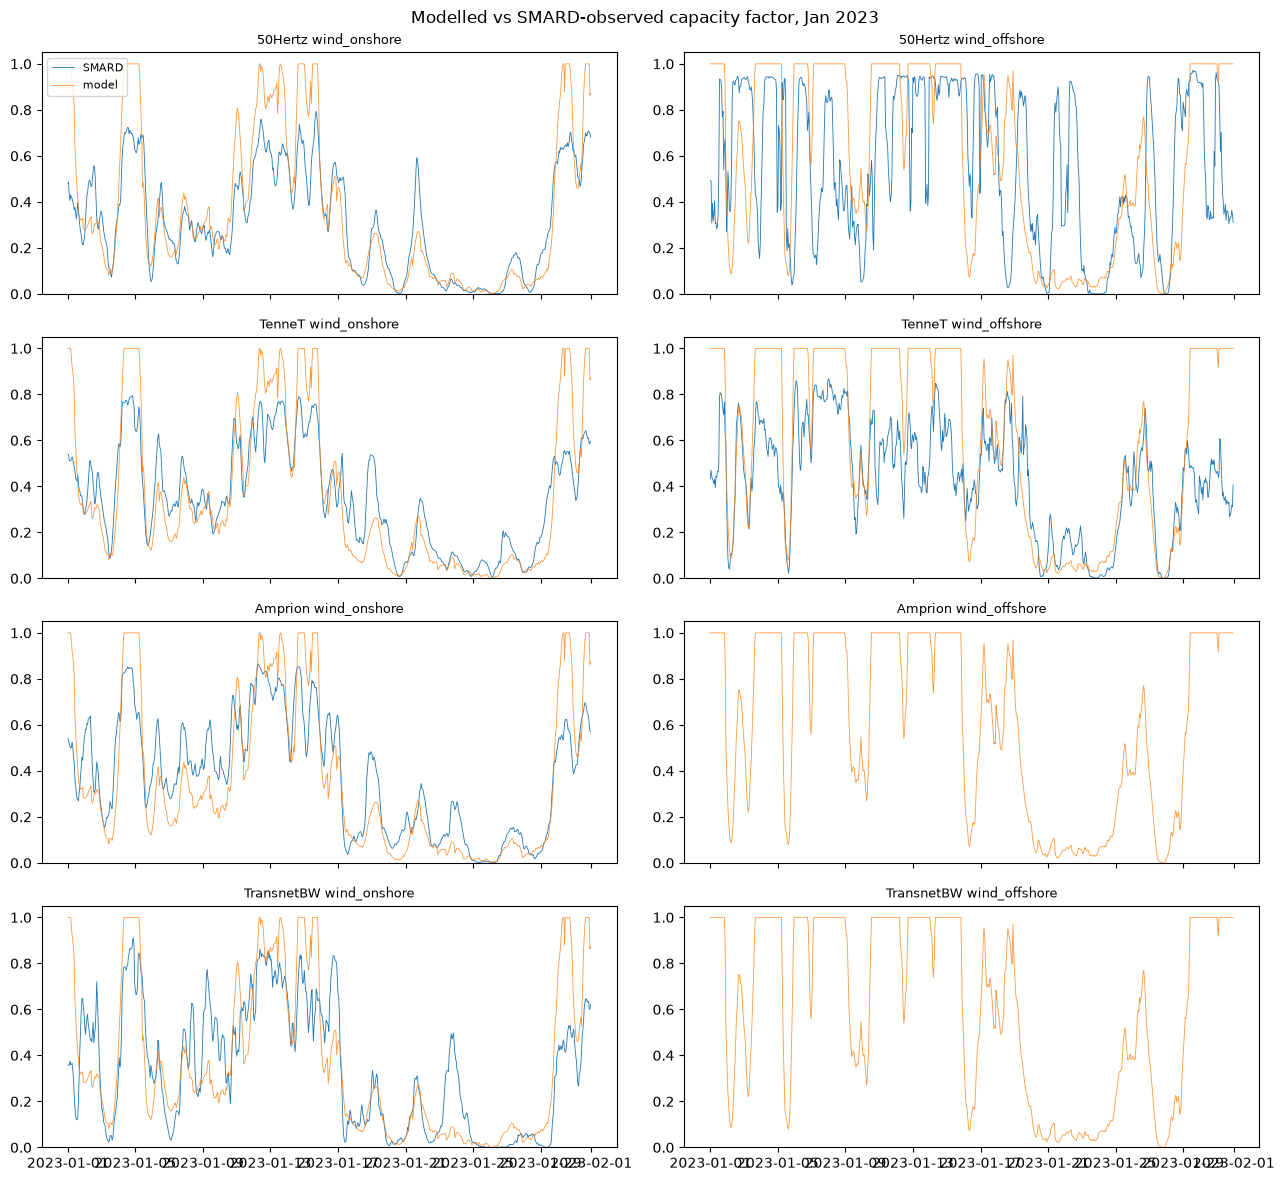

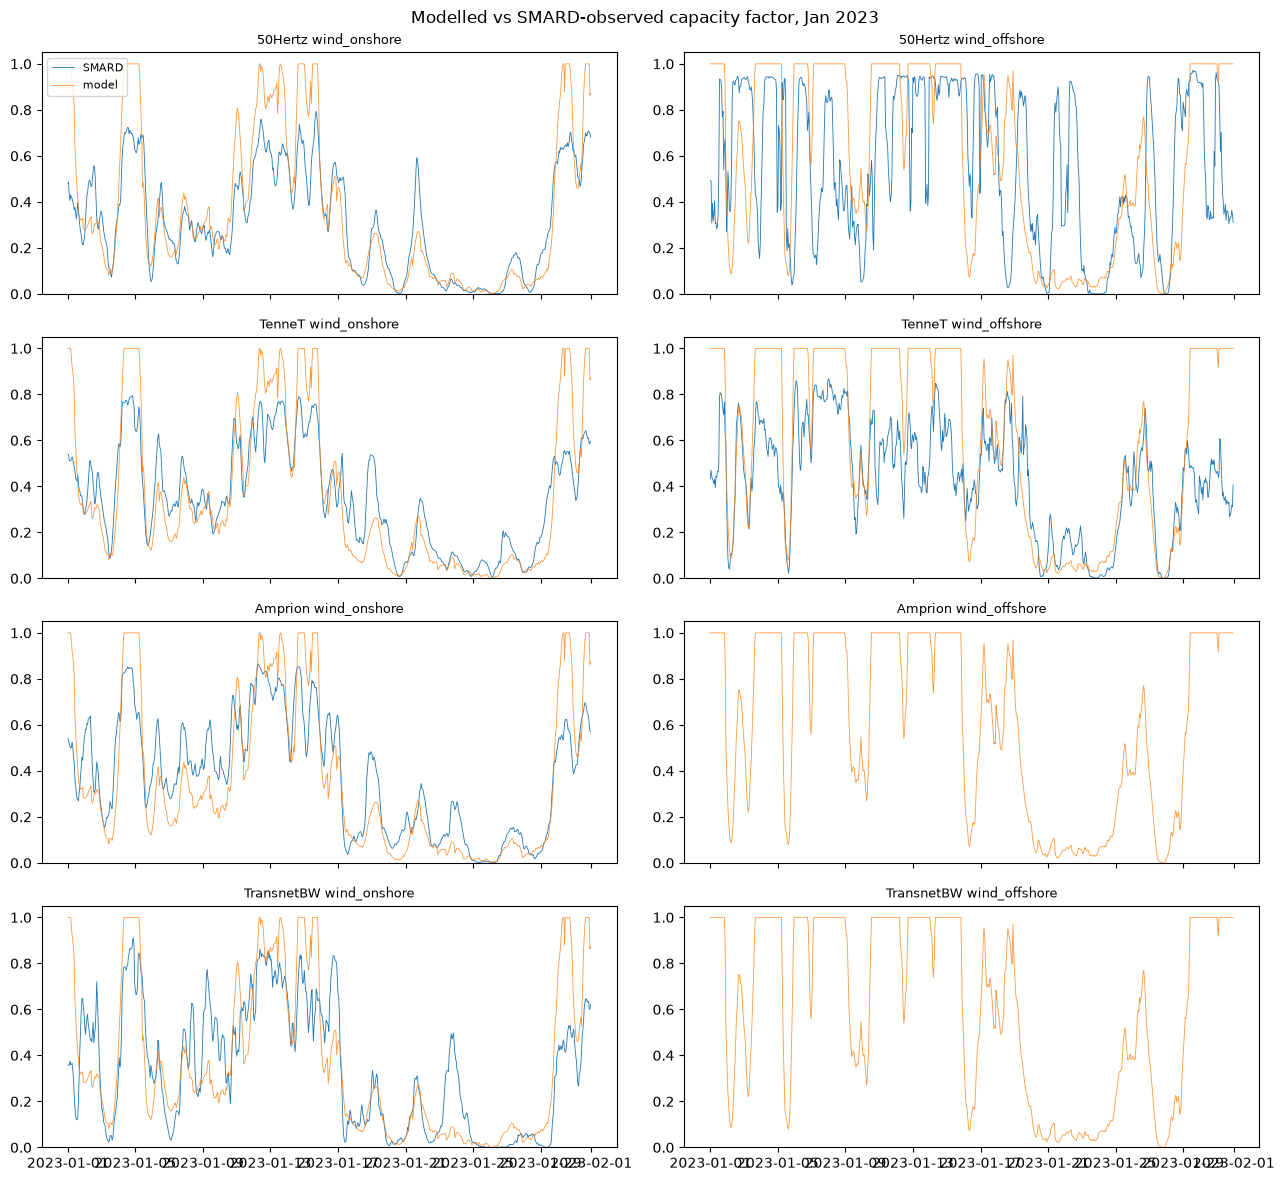

In [4]:
import matplotlib.pyplot as plt

cf_obs2 = cf_obs.join(cf_on.drop("variable"), on="time").rename({"cf_model": "cf_on"})
cf_obs2 = cf_obs2.join(cf_off.drop("variable"), on="time").rename({"cf_model": "cf_off"})
df = cf_obs2.to_pandas().set_index("time")

fig, axes = plt.subplots(4, 2, figsize=(13, 12), sharex=True)
for row, zone in enumerate(["50Hertz", "TenneT", "Amprion", "TransnetBW"]):
    for col, (var, cmod) in enumerate([("wind_onshore", "cf_on"), ("wind_offshore", "cf_off")]):
        ax = axes[row][col]
        j = df[(df["zone"] == zone) & (df["variable"] == var)]
        ax.plot(j.index, j["capacity_factor"], lw=0.6, label="SMARD")
        ax.plot(j.index, j[cmod], lw=0.6, label="model", alpha=0.8)
        ax.set_ylim(0, 1.05)
        ax.set_title(f"{zone} {var}", fontsize=9)
        if row == 0 and col == 0:
            ax.legend(fontsize=8)
fig.suptitle("Modelled vs SMARD-observed capacity factor, Jan 2023")
fig.tight_layout()
fig.savefig("/home/ubuntu/eurogrid/fig/phase03_transfer_validation.png", dpi=110)
fig

## Reading the bias
- Southern zones (Amprion, TransnetBW) share the Germany-wide onshore box → expect overprediction (fleet is northern).
- Jensen bias pushes modelled CF *down* in windy spells, *up* in calm spells.
- Missing wake/availability/curtailment losses (~10–15%) push modelled CF up uniformly.
- `corr` vs `bias_mw` separates causes: high corr + level bias ⇒ missing losses/aggregation; low corr ⇒ wrong space-time wind.